✅ Data loaded successfully! Total Records: 5000
Shape: (5000, 12)

Columns: ['patient_id', 'visit_date', 'age_group', 'gender', 'region', 'department', 'treatment_type', 'visit_type', 'length_of_stay_days', 'treatment_cost', 'recovery_score', 'readmission_risk']

First 5 rows:
   patient_id        visit_date age_group  gender region        department  \
0           1  01-01-2022 00:00     31-45    Male   West  General Medicine   
1           2  01-01-2022 01:00       60+  Female   West       Orthopedics   
2           3  01-01-2022 02:00     46-60    Male  South        Pediatrics   
3           4  01-01-2022 03:00     31-45  Female  North         Neurology   
4           5  01-01-2022 04:00     18-30  Female  North         Neurology   

  treatment_type visit_type  length_of_stay_days  treatment_cost  \
0     Medication  Emergency                  5.8           59151   
1        Surgery    Routine                  5.1           30272   
2    Observation    Routine                  7.9 

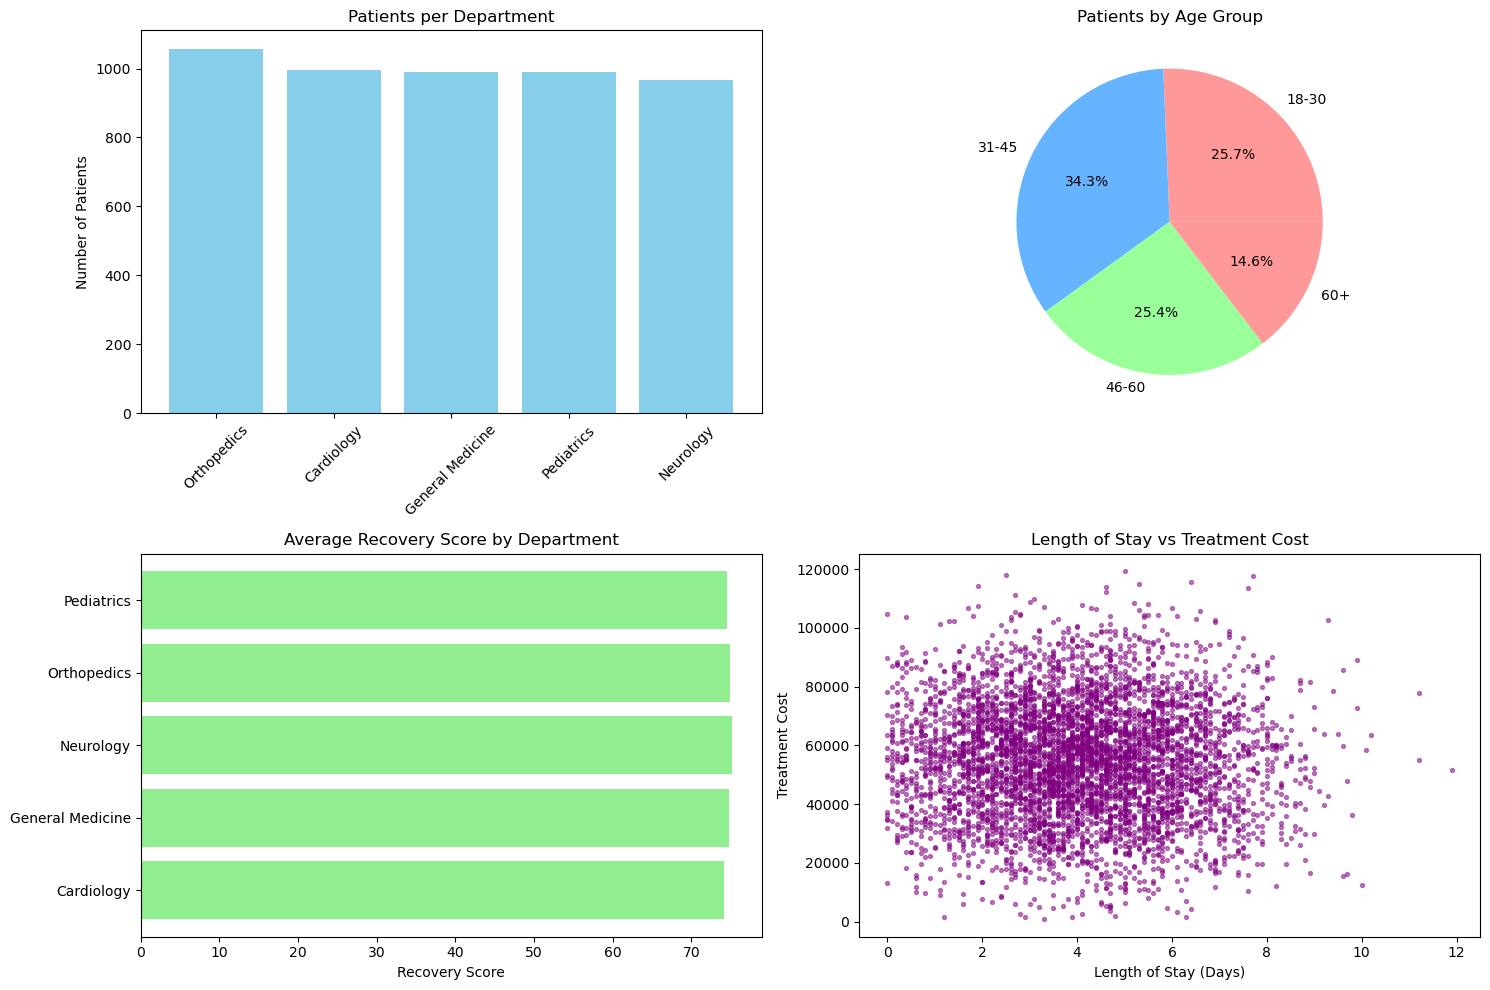


 HEALTHCARE ANALYTICS PROJECT COMPLETED SUCCESSFULLY!
Files Created:
   • healthcare.db
   • healthcare_analysis.png
   • healthcare_full_data.csv


In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import os

# ====================== CONFIG ======================
DB_NAME = 'healthcare.db'

# YOUR EXACT FILE PATH
FILE_PATH = r"C:\Users\rajendran\Desktop\HEALTHCARE ANALYSIS\DATASET.csv"

# ====================== LOAD DATA ======================
def load_data():
    df = pd.read_csv(FILE_PATH)
    print(f"✅ Data loaded successfully! Total Records: {len(df)}")
    print(f"Shape: {df.shape}")
    print("\nColumns:", df.columns.tolist())
    print("\nFirst 5 rows:")
    print(df.head())
    return df

# ====================== CREATE DATABASE ======================
def create_database(df):
    if os.path.exists(DB_NAME):
        os.remove(DB_NAME)
    
    conn = sqlite3.connect(DB_NAME)
    df.to_sql('patients', conn, index=False, if_exists='replace')
    print("✅ SQLite Database created successfully!")
    return conn

# ====================== ANALYSIS ======================
def run_analysis(conn):
    print("\n" + "="*75)
    print("🏥 HEALTHCARE PATIENT ANALYTICS DASHBOARD")
    print("="*75)

    queries = {
        "1. Overall Summary": """
            SELECT COUNT(*) as Total_Patients,
                   ROUND(AVG(length_of_stay_days), 2) as Avg_Stay_Days,
                   ROUND(AVG(treatment_cost), 2) as Avg_Treatment_Cost,
                   ROUND(AVG(recovery_score), 2) as Avg_Recovery_Score,
                   ROUND(AVG(readmission_risk), 3) as Avg_Readmission_Risk
            FROM patients""",

        "2. Department-wise Analysis": """
            SELECT department, 
                   COUNT(*) as Patient_Count,
                   ROUND(AVG(length_of_stay_days), 2) as Avg_Stay,
                   ROUND(AVG(treatment_cost), 2) as Avg_Cost,
                   ROUND(AVG(recovery_score), 2) as Avg_Recovery
            FROM patients 
            GROUP BY department 
            ORDER BY Patient_Count DESC""",

        "3. Age Group Analysis": """
            SELECT age_group, 
                   COUNT(*) as Count,
                   ROUND(AVG(length_of_stay_days), 2) as Avg_Stay,
                   ROUND(AVG(treatment_cost), 2) as Avg_Cost
            FROM patients GROUP BY age_group ORDER BY Count DESC""",

        "4. Gender-wise Performance": """
            SELECT gender, 
                   COUNT(*) as Count,
                   ROUND(AVG(length_of_stay_days), 2) as Avg_Stay,
                   ROUND(AVG(recovery_score), 2) as Avg_Recovery
            FROM patients GROUP BY gender""",

        "5. Emergency vs Routine Visits": """
            SELECT visit_type, 
                   COUNT(*) as Count,
                   ROUND(AVG(length_of_stay_days), 2) as Avg_Stay,
                   ROUND(AVG(treatment_cost), 2) as Avg_Cost
            FROM patients GROUP BY visit_type""",

        "6. High Readmission Risk Patients": """
            SELECT COUNT(*) as High_Risk_Count,
                   ROUND(AVG(recovery_score), 2) as Avg_Recovery
            FROM patients WHERE readmission_risk > 0.5"""
    }

    for title, query in queries.items():
        print(f"\n{title}")
        print("-" * len(title))
        result = pd.read_sql_query(query, conn)
        print(result.to_string(index=False))

# ====================== VISUALIZATIONS ======================
def create_visualizations(conn):
    plt.figure(figsize=(15, 10))

    # 1. Patients by Department
    plt.subplot(2, 2, 1)
    df1 = pd.read_sql_query("SELECT department, COUNT(*) as count FROM patients GROUP BY department ORDER BY count DESC", conn)
    plt.bar(df1['department'], df1['count'], color='skyblue')
    plt.title("Patients per Department")
    plt.xticks(rotation=45)
    plt.ylabel("Number of Patients")

    # 2. Age Group Distribution
    plt.subplot(2, 2, 2)
    df2 = pd.read_sql_query("SELECT age_group, COUNT(*) as count FROM patients GROUP BY age_group", conn)
    plt.pie(df2['count'], labels=df2['age_group'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
    plt.title("Patients by Age Group")

    # 3. Average Recovery by Department
    plt.subplot(2, 2, 3)
    df3 = pd.read_sql_query("SELECT department, AVG(recovery_score) as avg_recovery FROM patients GROUP BY department", conn)
    plt.barh(df3['department'], df3['avg_recovery'], color='lightgreen')
    plt.title("Average Recovery Score by Department")
    plt.xlabel("Recovery Score")

    # 4. Length of Stay vs Treatment Cost
    plt.subplot(2, 2, 4)
    df4 = pd.read_sql_query("SELECT length_of_stay_days, treatment_cost FROM patients", conn)
    plt.scatter(df4['length_of_stay_days'], df4['treatment_cost'], alpha=0.5, color='purple', s=8)
    plt.title("Length of Stay vs Treatment Cost")
    plt.xlabel("Length of Stay (Days)")
    plt.ylabel("Treatment Cost")

    plt.tight_layout()
    plt.savefig('healthcare_analysis.png', dpi=300, bbox_inches='tight')
    print("\n📊 Charts saved as 'healthcare_analysis.png'")
    plt.show()

# ====================== MAIN ======================
if __name__ == "__main__":
    df = load_data()
    conn = create_database(df)
    
    run_analysis(conn)
    create_visualizations(conn)
    
    # Export Reports
    pd.read_sql_query("SELECT * FROM patients", conn).to_csv('healthcare_full_data.csv', index=False)
    
    print("\n HEALTHCARE ANALYTICS PROJECT COMPLETED SUCCESSFULLY!")
    print("Files Created:")
    print("   • healthcare.db")
    print("   • healthcare_analysis.png")
    print("   • healthcare_full_data.csv")
    
    conn.close()